# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}


In [8]:
params =  {'m': -2, 'c': 1e8, 'l': 7e4}


In [9]:
data =  AS209

In [10]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [11]:
u.dtype

dtype('float64')

# Disk

In [12]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [13]:
best_params = best_AS209

Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...


--> time kernel = 0.06  min |  3.54 seconds
Using preconditioner method:  jacobi
--> time building system = 0.06  min |  3.63 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 2.881751982790494
Final tolerance :  2.881751982790494
.... iteration:  0
                        -> actual tol:  288175198.2790494 vs  2.881751982790494
.... iteration:  1
                        -> actual tol:  26326009.765339244 vs  2.881751982790494
.... iteration:  2
                        -> actual tol:  23214242.49799463 vs  2.881751982790494
.... iteration:  3
                        -> actual tol:  23233630.86969668 vs  2.881751982790494
.... iteration:  4
                        -> actual tol:  23003242.4621651 vs  2.881751982790494
.... iteration:  5
                        -> actual tol:  22241933.701379918 vs  2.881751982790494
.... iteration:  6
                        -> actual tol:  23846750.01607761 vs  2.8

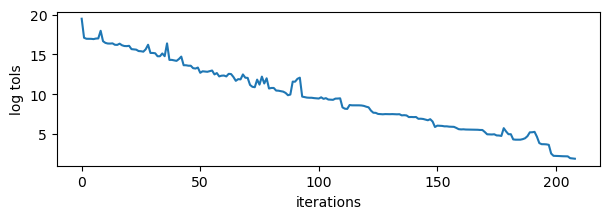

--> time = 0.75  min |  45.03 seconds
               ---> CGM converged?   True
                    x Fit correctly?   False
Building full visibility model...
--> times building full visibility model = 0.11  min |  6.77 seconds


In [14]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8)

### Sampler

In [15]:
# Multivariate Gaussian sampling with conjugate gradients 
def sampler_CG(mu,A,K,init,tol=1e-4,mode="precision",seed=None,size=1,info=False):
    r"""
    Algorithm dedicated to sample from a multivariate real-valued Gaussian 
    distribution :math:`\mathcal{N}(\boldsymbol{\mu},\mathbf{A})` or 
    :math:`\mathcal{N}(\boldsymbol{\mu},\mathbf{A}^{-1})` based on the
    conjugate gradient algorithm.
    
    Parameters
    ----------
    mu : 1-D array_like, of length d
        Mean of the d-dimensional Gaussian distribution.
    A : function
        Linear operator returning the matrix-vector product 
        :math:`\mathbf{Ax}` where :math:`\mathbf{x} \in \mathbb{R}^d`.
    K : int, optional
        Number of conjugate gradient iterations.
    init : 1-D array_like, of length d
        Vector used to initialize the CG sampler.
    tol : float, optional
        Tolerance threshold used to stop the conjugate gradient sampler.
    mode : string, optional
        Indicates if A refers to the precision or covariance matrix of the
        Gaussian distribution.
    seed : int, optional
           Random seed to reproduce experimental results.
    size : int, optional
        Given a size of for instance T, T independent and identically 
        distributed (i.i.d.) samples are returned.
    info : boolean, optional
        If info is True, returns the number of iterations :math:`K`.
        
    Returns
    -------
    theta : ndarray, of shape (d,size)
        The drawn samples, of shape (d,size), if that was provided. If not, 
        the shape is (d,1).
        
    Raises
    ------
    ValueError
        If mode is not included in ['covariance','precision'].
        
    Examples
    --------
    >>> d = 2
    >>> mu = np.zeros(d)
    >>> def A(x):
        return np.eye(d).dot(x)
    >>> K = 2
    >>> init = mu
    >>> theta = sampler_CG(mu,A,K,init)
    """ 

    # Set random seed
    np.random.seed(seed)
    
    d = len(mu)
    init = np.reshape(init,(d,1))
    mu = np.reshape(mu,(d,1))
    loss_conj = 0
        
    if mode == "precision":
        theta = np.zeros((d,size))
        # Initialization
        k = 1
        r_old = np.random.normal(0,1,size=(d,size)) - A(init)
        #rd = np.random.randint(0, 2, (d, size))
        #rd[rd == 0] = -1
        #r_old = rd - B(init)
        p_old = r_old
        d_old = (p_old * A(p_old)).sum(axis=0)
        y = init
        r_new = np.ones((d,size))
        loss_conj = 0
        while (col_vector_norms(r_new,2) >= tol).any() and k <= K:
            gam = (r_old * r_old).sum(axis=0) / d_old
            z = np.random.normal(0,1,size=size)
            y = y + z / np.sqrt(d_old) * p_old
            r_new = r_old - gam * A(p_old)
            beta = - (r_new * r_new).sum(axis=0) / (r_old * r_old).sum(axis=0)
            p_new = r_new - beta * p_old
            if (np.abs((p_new * A(p_old)).sum(axis=0)) >= 1e-4).any() and loss_conj == 0 and info==True:
                print('Loss of conjugacy happened at iteration k = %i.'%k)
                loss_conj = 1
                k_loss = k
            d_new = (p_new * A(p_new)).sum(axis=0)
            r_old = r_new
            p_old = p_new
            d_old = d_new
            k = k + 1
        theta = mu + y
        
        if info == True and loss_conj == 1:
            return (theta,k-1,loss_conj,k_loss)
        elif info == True and loss_conj == 0:
            return (theta,k-1,loss_conj)
        else:
            return theta
    
    elif mode == "covariance":
        theta = np.zeros((d,size))
        # Initialization
        k = 1
        r_old = np.random.normal(0,1,size=(d,size)) - A(init)
        #rd = np.random.randint(0, 2, (d, size))
        #rd[rd == 0] = -1
        #r_old = rd - A(init)
        p_old = r_old
        d_old = (p_old * A(p_old)).sum(axis=0)
        y = init
        r_new = np.ones((d,size))
        loss_conj = 0
        while (col_vector_norms(r_new,2) >= tol).any() and k <= K:
            gam = (r_old * r_old).sum(axis=0) / d_old
            z = np.random.normal(0,1,size=size)
            y = y + z / np.sqrt(d_old) * A(p_old)
            r_new = r_old - gam * A(p_old)
            beta = - (r_new * r_new).sum(axis=0) / (r_old * r_old).sum(axis=0)
            p_new = r_new - beta * p_old
            if (np.abs((p_new * A(p_old)).sum(axis=0)) >= 1e-4).any() and loss_conj == 0 and info==True:
                print('Loss of conjugacy happened at iteration k = %i.'%k)
                loss_conj = 1
                k_loss = k
            d_new = (p_new * A(p_new)).sum(axis=0)
            r_old = r_new
            p_old = p_new
            d_old = d_new
            k = k + 1
        theta = mu + y
        
        if info == True and loss_conj == 1:
            return (theta,k-1,loss_conj,k_loss)
        elif info == True and loss_conj == 0:
            return (theta,k-1,loss_conj)
        else:
            return theta
    
    else:
        str_list = ['Invalid mode input, choose among:',
                    '- "precision" (default)',
                    '- "covariance"',
                    'Given "{}"'.format(mode)]
        raise ValueError('\n'.join(str_list))

### Find M and $S^{-1}$ 

In [16]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry, N = 50)

In [17]:
#data = uvtable
#u, v, vis, weights = data['u'], data['v'], data['vis'], data['weights']
#ME._FF.fit(u, v, vis, weights)

In [18]:
data = frank2d.gridded_data
u, v, vis, weights = data['u'], data['v'], data['vis'], data['weights']
ME._FF.fit(u, v, vis, weights)

In [19]:
GM = ME._FF.GaussianModel

In [20]:
M = GM._M

In [21]:
M.shape

(2500, 2500)

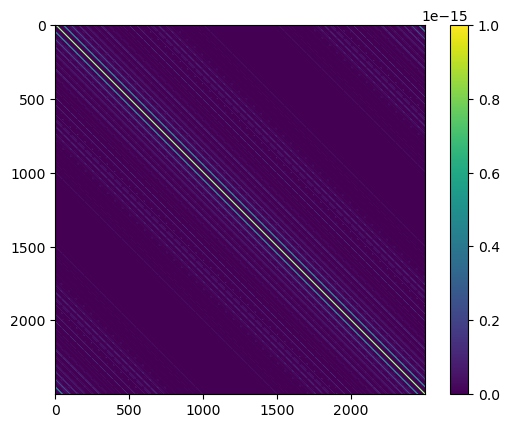

In [22]:
plt.imshow(M, vmin=0, vmax=1e-15)
plt.colorbar()

In [47]:
def sample_from_inv_cov_chol(M):
    L = np.linalg.cholesky(M)
    eta = np.random.randn(M.shape[0])
    z = np.linalg.solve(L, eta)  # equivale a L^{-1} eta
    return z

z_M = sample_from_inv_cov_chol(M)

* $S = F_{back}^{-1} \tilde{S} F_{back}$
* We want $z_S$ ~ $N(0, S^{-1})$, then solve with CGM $Sx = \eta$ with $\eta$~ N(0, I).

In [48]:
m, c, l = best_params['m'], best_params['c'], best_params['l']

In [50]:
S = GM.calculate_S_real_space(m, c, l)


In [54]:
# See github.
from scipy.sparse.linalg import LinearOperator, cg

def matvec_S(v):
    return S @ v

mu = np.zeros(n)
init = np.zeros(n)

z_S = sampler_CG(mu, A_S, K, init, mode="precision")
z_S = z_S.squeeze()  # (d,)
# z_S ~ N(0, S^{-1})



In [55]:
z_S

array([ 2.58893096e-16,  1.13547971e-16,  3.99580896e-16, ...,
        4.18178882e-16, -2.83402710e-16, -3.20797452e-16])

In [56]:
z = z_M + z_S

Solve $D^{-1} x = j + z$ with CGM

In [58]:
j = GM._j

In [59]:
b = j + z

In [ ]:
x, info = cg(LinearOperator((n,n), matvec=lambda v: matvec_M(v) + matvec_S(v)), M_mu + z)
